Primero miremos la fuente de error que aparece cuando no consideramos sino una muestra y no toda la población. Por supuesto haremos una muestra exageradamente pequeña, para poder mostrar este error claramente. 


--- Ecuación de Regresión Lineal (Datos Completos) ---
p = 5.02 * a + 49.23
ECM = 1366.25

--- Ecuación de Regresión Lineal (Subgrupo 1) ---
p = 7.23 * a + -141.16
ECM = 2883.81

--- Ecuación de Regresión Lineal (Subgrupo 2) ---
p = 3.48 * a + 195.32
ECM = 2738.50


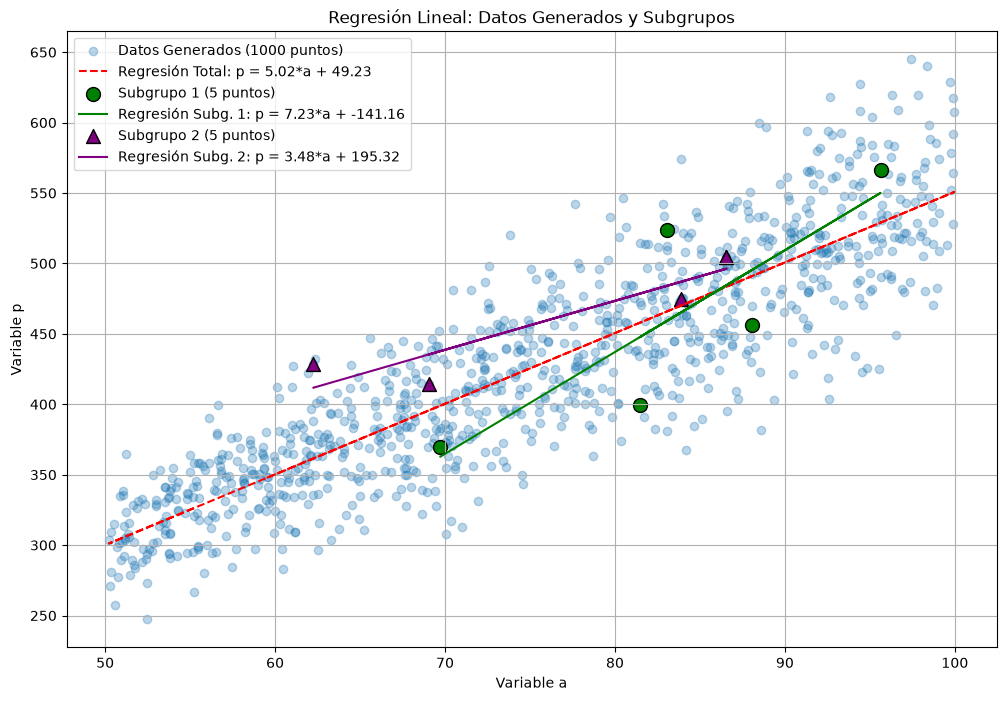

In [7]:
import numpy as np
import json
from scipy.stats import linregress
import matplotlib.pyplot as plt
import pandas as pd


data_ap=json.load(open('data_area_precio.json'))

# Convertir a DataFrame para facilitar el manejo
df_ap = pd.DataFrame(data_ap)
num_data_points=len(df_ap)
# 2. Regresión lineal para el conjunto completo de datos
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(df_ap['a'], df_ap['p'])
y_est=slope_full * df_ap['a'] + intercept_full
ECM = np.mean((df_ap['p'] - y_est) ** 2)
print("\n--- Ecuación de Regresión Lineal (Datos Completos) ---")
print(f"p = {slope_full:.2f} * a + {intercept_full:.2f}")
print(f"ECM = {ECM:.2f}")

# 3. Generar 2 subgrupos de 5 datos y hacer regresión lineal

# Subgrupo 1
subgroup1_indices = np.random.choice(num_data_points, 5, replace=False)
df_subgroup1 = df_ap.iloc[subgroup1_indices]

slope_s1, intercept_s1, r_value_s1, p_value_s1, std_err_s1 = linregress(df_subgroup1['a'], df_subgroup1['p'])
y_est_s1 = slope_s1 * df_ap['a'] + intercept_s1
ECM_s1 = np.mean((df_ap['p'] - y_est_s1) ** 2)
print("\n--- Ecuación de Regresión Lineal (Subgrupo 1) ---")
print(f"p = {slope_s1:.2f} * a + {intercept_s1:.2f}")
print(f"ECM = {ECM_s1:.2f}")

# Subgrupo 2
# Asegurarse de que el subgrupo 2 no tenga los mismos datos que el subgrupo 1
remaining_indices = list(set(range(num_data_points)) - set(subgroup1_indices))
subgroup2_indices = np.random.choice(remaining_indices, 5, replace=False)
df_subgroup2 = df_ap.iloc[subgroup2_indices]

slope_s2, intercept_s2, r_value_s2, p_value_s2, std_err_s2 = linregress(df_subgroup2['a'], df_subgroup2['p'])
y_est_s2 = slope_s2 * df_ap['a'] + intercept_s2
ECM_s2 = np.mean((df_ap['p'] - y_est_s2) ** 2)
print("\n--- Ecuación de Regresión Lineal (Subgrupo 2) ---")
print(f"p = {slope_s2:.2f} * a + {intercept_s2:.2f}")
print(f"ECM = {ECM_s2:.2f}")

# Visualización
plt.figure(figsize=(12, 8))
plt.scatter(df_ap['a'], df_ap['p'], alpha=0.3, label='Datos Generados (1000 puntos)')

# Línea de regresión para todos los datos
plt.plot(df_ap['a'], slope_full * df_ap['a'] + intercept_full, color='red', linestyle='--', label=f'Regresión Total: p = {slope_full:.2f}*a + {intercept_full:.2f}')

# Puntos y líneas de regresión para subgrupos
plt.scatter(df_subgroup1['a'], df_subgroup1['p'], color='green', marker='o', s=100, edgecolors='black', label='Subgrupo 1 (5 puntos)')
plt.plot(df_subgroup1['a'], slope_s1 * df_subgroup1['a'] + intercept_s1, color='green', linestyle='-', label=f'Regresión Subg. 1: p = {slope_s1:.2f}*a + {intercept_s1:.2f}')

plt.scatter(df_subgroup2['a'], df_subgroup2['p'], color='purple', marker='^', s=100, edgecolors='black', label='Subgrupo 2 (5 puntos)')
plt.plot(df_subgroup2['a'], slope_s2 * df_subgroup2['a'] + intercept_s2, color='purple', linestyle='-', label=f'Regresión Subg. 2: p = {slope_s2:.2f}*a + {intercept_s2:.2f}')

plt.title('Regresión Lineal: Datos Generados y Subgrupos')
plt.xlabel('Variable a')
plt.ylabel('Variable p')
plt.legend()
plt.grid(True)
plt.show()


Ahora miremos un error estructural que sale de utilizar el modelo no apropiado para describir los datos. En este caso el error no será posible reducirlo a menos que se utilice el modelo apropiado. 


--- Regresión Lineal (Orden 1) ---
Ecuación: y = -0.0430 + -0.9842 * x
Error Cuadrático Medio (MSE): 7.5869

--- Regresión Polinomial (Orden 2) ---
Ecuación: y = -1.9781 + -0.9984*x + 0.2397*x^2
Error Cuadrático Medio (MSE): 4.3604

--- Regresión Polinomial (Orden 3) ---
Ecuación: y = -2.0157 + 0.5202*x + 0.2499*x^2 + -0.1011*x^3
Error Cuadrático Medio (MSE): 0.7415


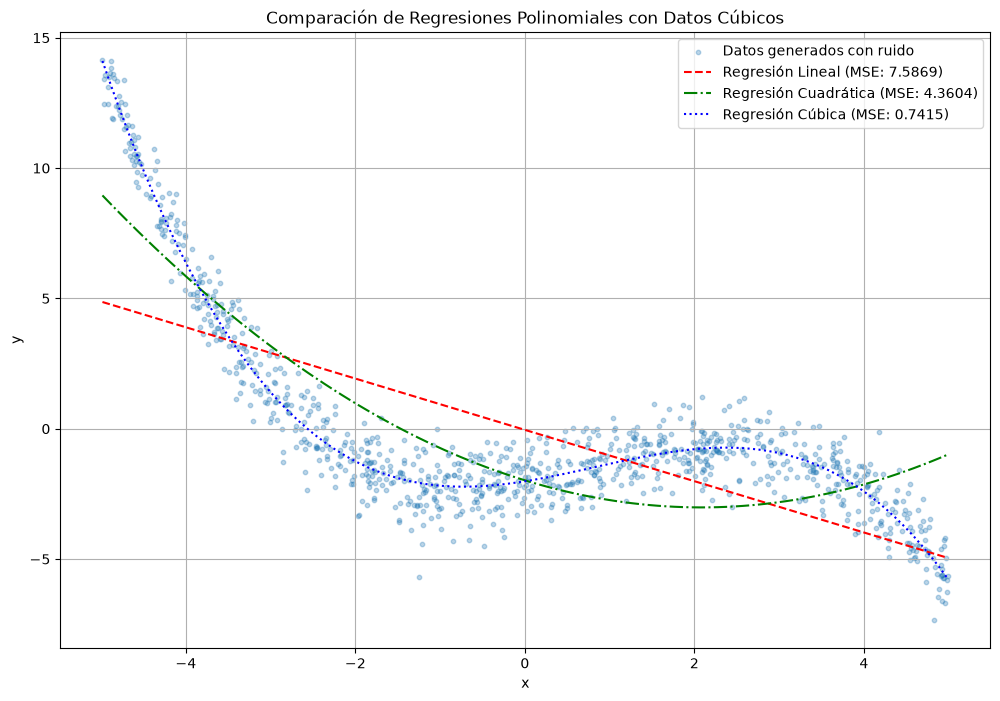

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

data_structural_error=json.load(open('datos_error_estructural.json'))

# Convertir a DataFrame para facilitar el manejo
data_structural_error = pd.DataFrame(data_structural_error)
num_data_points=len(data_structural_error)
x_data = data_structural_error['x'].values
y_data = data_structural_error['y'].values
x_range = np.linspace(min(x_data), max(x_data), 100)
# 3. Regresión Lineal (Orden 1)
X_data_reshaped = x_data.reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X_data_reshaped, y_data)
y_pred_linear = linear_model.predict(X_data_reshaped)
mse_linear = mean_squared_error(y_data, y_pred_linear)

print("\n--- Regresión Lineal (Orden 1) ---")
print(f"Ecuación: y = {linear_model.intercept_:.4f} + {linear_model.coef_[0]:.4f} * x")
print(f"Error Cuadrático Medio (MSE): {mse_linear:.4f}")

# 4. Regresión Polinomial (Orden 2)
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_data_reshaped)

poly2_model = LinearRegression()
poly2_model.fit(X_poly2, y_data)
y_pred_poly2 = poly2_model.predict(X_poly2)
mse_poly2 = mean_squared_error(y_data, y_pred_poly2)

print("\n--- Regresión Polinomial (Orden 2) ---")
# Coeficientes: intercept_, coef_[0] (x^0), coef_[1] (x^1), coef_[2] (x^2)
print(f"Ecuación: y = {poly2_model.intercept_:.4f} + {poly2_model.coef_[1]:.4f}*x + {poly2_model.coef_[2]:.4f}*x^2")
print(f"Error Cuadrático Medio (MSE): {mse_poly2:.4f}")

# 5. Regresión Polinomial (Orden 3)
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_data_reshaped)

poly3_model = LinearRegression()
poly3_model.fit(X_poly3, y_data)
y_pred_poly3 = poly3_model.predict(X_poly3)
mse_poly3 = mean_squared_error(y_data, y_pred_poly3)

print("\n--- Regresión Polinomial (Orden 3) ---")
# Coeficientes: intercept_, coef_[0] (x^0), coef_[1] (x^1), coef_[2] (x^2), coef_[3] (x^3)
print(f"Ecuación: y = {poly3_model.intercept_:.4f} + {poly3_model.coef_[1]:.4f}*x + {poly3_model.coef_[2]:.4f}*x^2 + {poly3_model.coef_[3]:.4f}*x^3")
print(f"Error Cuadrático Medio (MSE): {mse_poly3:.4f}")

# 6. Gráfica de la función original, los datos y las regresiones
plt.figure(figsize=(12, 8))
plt.scatter(x_data, y_data, s=10, alpha=0.3, label='Datos generados con ruido')
#plt.plot(x_range, y_true, color='black', linewidth=2, label='Función Original')

# Predicciones para las regresiones sobre el rango de la función original para una visualización suave
X_range_reshaped = x_range.reshape(-1, 1)

plt.plot(x_range, linear_model.predict(X_range_reshaped), color='red', linestyle='--', label=f'Regresión Lineal (MSE: {mse_linear:.4f})')

plt.plot(x_range, poly2_model.predict(poly2.transform(X_range_reshaped)), color='green', linestyle='-.', label=f'Regresión Cuadrática (MSE: {mse_poly2:.4f})')

plt.plot(x_range, poly3_model.predict(poly3.transform(X_range_reshaped)), color='blue', linestyle=':', label=f'Regresión Cúbica (MSE: {mse_poly3:.4f})')

plt.title('Comparación de Regresiones Polinomiales con Datos Cúbicos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


Finalmente en todos los modelos anteriores, aunque tengamos el modelo exácto y todos los datos disponibles, el modelo no alcanza a eliminar el error aleatorio. Esto es parte del modelo y no es posible eliminarlo, excepto que un modelo "aprenda el error también". Pero esto es un resultado no deseado. 


In [ ]:
#Me falta instalar pytorch para poder mostrar el modelo con redes neuronales, ya que no tengo acceso a internet para instalarlo.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import mean_squared_error
import pandas as pd

# 1. Cargar los datos desde el archivo JSON
output_filename_structural = "datos_error_estructural.json"
with open(output_filename_structural, "r") as f:
    data_structural_error = json.load(f)

# Convertir a DataFrame para facilitar el manejo
df_data = pd.DataFrame(data_structural_error)

x_data_np = df_data['x'].values.astype(np.float32)
y_data_np = df_data['y'].values.astype(np.float32)

# Convertir a tensores de PyTorch
x_tensor = torch.tensor(x_data_np).unsqueeze(1) # Añadir dimensión para features
y_tensor = torch.tensor(y_data_np).unsqueeze(1) # Añadir dimensión para output

# Crear Dataset y DataLoader
dataset = TensorDataset(x_tensor, y_tensor)
batch_size = 100
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 2. Definir la Red Neuronal
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.layer_in = nn.Linear(1, 10)  # Capa de entrada: 1 feature a 10 neuronas
        self.hidden1 = nn.Linear(10, 30) # Primera capa oculta
        self.hidden2 = nn.Linear(30, 50) # Segunda capa oculta
        self.hidden3 = nn.Linear(50, 30) # Tercera capa oculta
        self.hidden4 = nn.Linear(30, 10) # Cuarta capa oculta
        self.hidden5 = nn.Linear(10, 10) # Quinta capa oculta
        self.layer_out = nn.Linear(10, 1) # Capa de salida: 10 neuronas a 1 output
        self.activation = nn.LeakyReLU() # Función de activación Leaky ReLU

    def forward(self, x):
        x = self.activation(self.layer_in(x))
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.activation(self.hidden3(x))
        x = self.activation(self.hidden4(x))
        x = self.activation(self.hidden5(x))
        x = self.layer_out(x) # La capa de salida no lleva activación si es regresión
        return x

# Instanciar el modelo
model = NeuralNetwork()

# Definir función de pérdida y optimizador
criterion = nn.MSELoss() # Error Cuadrático Medio
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Optimizador Adam

# 3. Entrenamiento del modelo
num_epochs = 5000 # Aumentar las épocas a 5000
losses = []

print("\n--- Iniciando entrenamiento de la Red Neuronal ---")
for epoch in range(num_epochs):
    epoch_loss = 0
    for inputs, targets in dataloader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(dataloader)
    losses.append(avg_epoch_loss)
    if (epoch + 1) % 50 == 0: # Imprimir cada 50 épocas
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}')

print("--- Entrenamiento finalizado ---")

# 4. Evaluación y Visualización

# Generar predicciones del modelo en un rango suave para la gráfica
# Usar el mismo x_range de los datos para una visualización consistente
x_range_np = np.linspace(x_data_np.min(), x_data_np.max(), 400).astype(np.float32)
x_range_tensor = torch.tensor(x_range_np).unsqueeze(1)

model.eval() # Poner el modelo en modo evaluación
with torch.no_grad(): # Desactivar cálculo de gradientes
    y_pred_nn_tensor = model(x_range_tensor)
y_pred_nn = y_pred_nn_tensor.squeeze().numpy()

# Calcular MSE de la red neuronal sobre los datos originales (entrenamiento)
model.eval()
with torch.no_grad():
    y_pred_data_tensor = model(x_tensor)
y_pred_data_nn = y_pred_data_tensor.squeeze().numpy()
mse_nn = mean_squared_error(y_data_np, y_pred_data_nn)
print(f"\nError Cuadrático Medio (MSE) de la Red Neuronal sobre los datos originales: {mse_nn:.4f}")

plt.figure(figsize=(12, 8))
plt.scatter(x_data_np, y_data_np, s=10, alpha=0.3, label='Datos generados con ruido')
# Ya no graficamos la "Función Original (Ground Truth)"
plt.plot(x_range_np, y_pred_nn, color='blue', linestyle='-', linewidth=2, label=f'Red Neuronal (MSE: {mse_nn:.4f})')

plt.title('Regresión con Red Neuronal: Datos Cúbicos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Opcional: Gráfica de la pérdida durante el entrenamiento
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, num_epochs + 1), losses, marker='o', linestyle='-')
plt.title('Pérdida (MSE) durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()